### Setup and imports

In [1]:
import logging

import sys

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.handlers:

    console_handler = logging.StreamHandler(sys.stdout)  # ← fix
    file_handler = logging.FileHandler("run.log")

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s"
    )

    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)
logger.info("test")

2026-04-17 01:41:19,657 | INFO | test


In [2]:
# !pip install wandb -q
# !pip install timm -q
# !pip install torchvisionlogger.info('Starting setup and imports')

logger.info('\nStarting setup and imports')

import random
import math
import os, json, time, warnings
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR #baseline
from torchvision import transforms #for iamge preprocessing, e.g. resize, augmentation etc
 
from sklearn.model_selection import GroupShuffleSplit #for lesion_id split later
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)
 
warnings.filterwarnings("ignore")
logger.info("Imports OK")
import subprocess, zipfile

on_aws = True

if on_aws:
    # PATHS 
    uvaid="dpy8wq"
    DATA_ROOT = f"/home/ubuntu/{uvaid}/isic2019"    
    TEST_INPUT = f"{DATA_ROOT}/ISIC_2019_Test_Input"
    TRAIN_INPUT = f"{DATA_ROOT}/ISIC_2019_Training_Input"
    CKPT_DIR  = "/home/ubuntu/{uvaid}/isic2019/checkpoints"
else:
    # PATHS 
    DATA_ROOT = "/scratch/wpl3a/isic2019"
    TEST_INPUT = f"{DATA_ROOT}/ISIC_2019_Test_Input"
    TRAIN_INPUT = f"{DATA_ROOT}/ISIC_2019_Training_Input"
    CKPT_DIR  = "/scratch/wpl3a/isic2019/checkpoints"

os.makedirs(DATA_ROOT, exist_ok=True)
 
BASE_URL = "https://isic-archive.s3.amazonaws.com/challenges/2019"

2026-04-17 01:41:19,667 | INFO | 
Starting setup and imports
2026-04-17 01:41:24,322 | INFO | Imports OK


In [3]:
os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
wandb.login()

logger.info('\nSetup and imports complete')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/ubuntu/.netrc.
wandb: Currently logged in as: dpy8wq (vrb9e-university-of-virginia-school-of-data-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-04-17 01:41:24,950 | INFO | 
Setup and imports complete


### Download and unzip ISIC dataset

In [4]:
# Download CSVs & zips 
DOWNLOADS = [
    (f"{BASE_URL}/ISIC_2019_Training_GroundTruth.csv", f"{DATA_ROOT}/train_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Metadata.csv",    f"{DATA_ROOT}/train_meta.csv"),
    (f"{BASE_URL}/ISIC_2019_Test_GroundTruth.csv",     f"{DATA_ROOT}/test_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Input.zip",       f"{DATA_ROOT}/train_imgs.zip"),
    (f"{BASE_URL}/ISIC_2019_Test_Input.zip",           f"{DATA_ROOT}/test_imgs.zip"),
]

# If already downloaded, do not download and unzip!!
if not len([f for f in os.listdir(TEST_INPUT) if f.endswith('.jpg')]) == 8238 and \
    len([f for f in os.listdir(TRAIN_INPUT) if f.endswith('.jpg')]) == 25331:
    for url, dest in DOWNLOADS:
            logger.info(f"Downloading {os.path.basename(dest)} ...")
            subprocess.run(
                ["curl", "--location", "--progress-bar",
                 "--retry", "3", "--retry-delay", "5",
                 "--output", dest, url],
                check=True,
            )
    # Unzip
    for zip_path, extract_dir in [
        (f"{DATA_ROOT}/train_imgs.zip", DATA_ROOT),
        (f"{DATA_ROOT}/test_imgs.zip",  DATA_ROOT),
    ]:
        logger.info(f"Extracting {os.path.basename(zip_path)} ...")
        # Sanity check
        size_mb = os.path.getsize(zip_path) / (1024**2)
        logger.info(f"  File size: {size_mb:.1f} MB")
        if size_mb < 1:
            raise RuntimeError(f"File too small — download likely failed: {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        os.remove(zip_path)
        logger.info(f"  Done & removed {os.path.basename(zip_path)}")
else:
    logger.info('\nData files already present, skipping download and unzip')


2026-04-17 01:41:24,964 | INFO | 
Data files already present, skipping download and unzip


In [5]:
# Path 
TRAIN_DIR  = os.path.join(DATA_ROOT, "ISIC_2019_Training_Input")
TEST_DIR   = os.path.join(DATA_ROOT, "ISIC_2019_Test_Input")
TRAIN_CSV  = os.path.join(DATA_ROOT, "train_gt.csv")
TEST_CSV   = os.path.join(DATA_ROOT, "test_gt.csv")
TRAIN_META = os.path.join(DATA_ROOT, "train_meta.csv")
 
logger.info("\nData ready - downloaded and unzipped.")

2026-04-17 01:41:24,969 | INFO | 
Data ready - downloaded and unzipped.


### Config and Setup

In [6]:
Config = {
    # model
    "architecture": "mobilenet_v3_small",  # "resnet-50" | "mobilenetv3_small" | efficientnet_b0
    "pretrained":   True,              # False = train from scratch ablation
    "freeze_bb":    True,             # True = head-only training ablation
    "loss_fn":      "focal",      # "ce" | "weighted_ce | "focal"
    "augmentation": "standard",           # "none" | "geometric" | "color" | "standard"
    "img_size":     224,
    "batch_size":   32,
    "epochs":       30,
    "lr":           1e-4,
    "val_split":    0.20,
    "patience":     10,                #stop epoch if no improvement for 10
    "seed":         42,                #set_seed for reproducibility 
    "classes":      ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"],
    "min_delta":    .001,
}
Config["num_classes"] = len(Config["classes"])
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"\nDevice: {device}")
logger.info(f"Config: {Config}")

2026-04-17 01:41:24,995 | INFO | 
Device: cuda
2026-04-17 01:41:24,995 | INFO | Config: {'architecture': 'mobilenet_v3_small', 'pretrained': True, 'freeze_bb': True, 'loss_fn': 'focal', 'augmentation': 'standard', 'img_size': 224, 'batch_size': 32, 'epochs': 30, 'lr': 0.0001, 'val_split': 0.2, 'patience': 10, 'seed': 42, 'classes': ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC'], 'min_delta': 0.001, 'num_classes': 8}


In [7]:
# seed value is in Config
def set_seed(seed=Config["seed"]):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
logger.info(f"\nSeed set to {Config['seed']}")

2026-04-17 01:41:25,003 | INFO | 
Seed set to 42


### Add class so Focal Loss can be invoked; Focal Loss not built into PyTorch

In [8]:
# focal loss not built in to PyTorch
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # class weights tensor or None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [9]:
#Dataset 

class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(f"{self.img_dir}/{row['image']}.jpg").convert("RGB")
        
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

def get_transforms(split):
    aug = Config["augmentation"]
    
    if split in ("val", "test"):
        return transforms.Compose([
            transforms.Resize((Config["img_size"], Config["img_size"])),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    
    # Train transforms vary by augmentation setting in the Config code cell
    if aug == "none":
        aug_tfms = []
    elif aug == "geometric":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(degrees=15),
        ]
    elif aug == "color":
        aug_tfms = [
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ]
    elif aug == "standard":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomRotation(degrees=15),
        ]
    
    return transforms.Compose([
        transforms.Resize((Config["img_size"], Config["img_size"])),
        *aug_tfms,
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

In [10]:
### DUPLICATE WITH FOLLOWING CELL - FIX!!
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small

# Load pretrained model
model = mobilenet_v3_small(weights="IMAGENET1K_V1")

# Replace classifier for your dataset
num_classes = 10  # change this!
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

In [11]:
# import torch.nn as nn
# from torchvision.models import mobilenet_v3_small

def build_model(num_classes=Config["num_classes"]):
    weights = "IMAGENET1K_V1" if Config["pretrained"] else None
    
    model = mobilenet_v3_small(weights=weights)

    # Freeze backbone if requested <-- ChatGPT addition to freeze backbone
    if Config["freeze_bb"]:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    
    return model

model = build_model().to(device)

logger.info("\nModel loaded OK")
logger.info(type(model))

2026-04-17 01:41:25,375 | INFO | 
Model loaded OK
2026-04-17 01:41:25,376 | INFO | <class 'torchvision.models.mobilenetv3.MobileNetV3'>


In [12]:
#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"

# create tracked experiment run with labeled hyperparameters so you can analyze and compare results later

# entity → team/org/account in wandb
# project → folder for related experiments
# Run name → important for comparisons

# config={ ... } → logs hyperparameters:
#     model settings (architecture, pretrained, freeze_bb)
#     training settings (lr, batch_size, epochs)
#     early stopping (patience, min_delta)
#     reproducibility (seed)

# Stored so you can:
#     compare runs side-by-side
#     filter experiments (e.g., “show only focal loss runs”)
#     Reproduce results laterr
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
        "min_delta":     Config["min_delta"],
    }
)

### Training Loop - one_epoch

In [13]:
import torch.nn.functional as F
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

### Set Up Evaluation Metrics

In [14]:
# ChaptGPT assisted modifying function (created for Milestone II) to return two extra values: 
#     precision_per / recall_per (per-class arrays, computed from the same confusion-matrix loop that already existed)
#     and aggregates (a dict) and cm (the raw confusion matrix). 
#     The sensitivity/recall relationship (recall == sensitivity) is made explicit with a comment
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs   = F.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    num_cls    = Config["num_classes"]
    cls_range  = list(range(num_cls))

    # ── Core metrics ──────────────────────────────────────────────────────────
    acc  = (all_preds == all_labels).mean()
    bacc = balanced_accuracy_score(all_labels, all_preds)

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds, labels=cls_range)

    # ── Per-class: sensitivity, specificity, precision, recall, F1 ───────────
    sensitivity, specificity, f1_per, precision_per, recall_per = [], [], [], [], []

    for i in range(num_cls):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = sens                                          # recall == sensitivity
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

        sensitivity.append(sens)
        specificity.append(spec)
        precision_per.append(prec)
        recall_per.append(rec)
        f1_per.append(f1)

    sensitivity   = np.array(sensitivity)
    specificity   = np.array(specificity)
    precision_per = np.array(precision_per)
    recall_per    = np.array(recall_per)
    f1_per        = np.array(f1_per)

    # ── Aggregate: macro & weighted precision / recall / F1 ──────────────────
    # sklearn handles zero-division and class weighting cleanly
    macro_precision = precision_score(all_labels, all_preds, average="macro",    zero_division=0)
    macro_recall    = recall_score   (all_labels, all_preds, average="macro",    zero_division=0)
    macro_f1        = f1_score       (all_labels, all_preds, average="macro",    zero_division=0)
    wtd_precision   = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    wtd_recall      = recall_score   (all_labels, all_preds, average="weighted", zero_division=0)
    wtd_f1          = f1_score       (all_labels, all_preds, average="weighted", zero_division=0)

    # ── AUC per class + macro ─────────────────────────────────────────────────
    auc_per_class = {}
    for i, cls in enumerate(Config["classes"]):
        try:
            auc_per_class[cls] = roc_auc_score(
                (all_labels == i).astype(int), all_probs[:, i]
            )
        except ValueError:
            auc_per_class[cls] = float("nan")

    # bundle aggregates for convenient access downstream
    aggregates = {
        "macro_precision": macro_precision,
        "macro_recall":    macro_recall,
        "macro_f1":        macro_f1,
        "wtd_precision":   wtd_precision,
        "wtd_recall":      wtd_recall,
        "wtd_f1":          wtd_f1,
    }

    return (
        acc, bacc,
        sensitivity, specificity,
        precision_per, recall_per, f1_per,
        auc_per_class,
        cm,
        aggregates,
    )

### Set Up Confusion Matrix Plot

In [15]:
# CONFUSION MATRIX   <-- nifty ChatGPT helper adding confusion matrix

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix",
                          save_path=None):
    """Print, plot, and optionally save a confusion matrix."""
    # printed version
    logger.info(f"\n{title}")
    header = "      " + "  ".join(f"{c:>5}" for c in class_names)
    logger.info(header)
    for i, row_cls in enumerate(class_names):
        row_str = "  ".join(f"{v:5d}" for v in cm[i])
        logger.info(f"  {row_cls:>4}  {row_str}")

    # plotted version
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        logger.info(f"Confusion matrix saved → {save_path}")
    plt.show()

### Split input data into Train, Validation, and Test Datasets

In [16]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Convert label column
train_df["label"] = train_df[Config["classes"]].values.argmax(axis=1)
test_df["label"]  = test_df[Config["classes"]].values.argmax(axis=1)

# Train/val split stratified by label...to be improved later by adding patient-level split with lesion_id(GroupShuffleSplit)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    train_df,
    test_size=Config["val_split"],
    stratify=train_df["label"],
    random_state=Config["seed"],
)

logger.info(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

2026-04-17 01:41:27,217 | INFO | 
Train: 20264 | Val: 5067 | Test: 8238


### Calculate Class frequencies - review for Class Imbalance?

In [17]:
#show class imbalance in frequency table
counts        = train_df["label"].value_counts().sort_index()
CLASS_FREQ    = (counts / counts.sum()).to_dict()

logger.info("\nClass frequencies:")

for name, df_ in [("TRAIN", train_df), ("VAL", val_df)]:
    labels = df_[Config["classes"]].values.argmax(axis=1)
    cnts   = np.bincount(labels, minlength=len(Config["classes"]))

    logger.info(f"\n{name} ({len(df_)} images):")
    for i, c in enumerate(Config["classes"]):
        logger.info(f"  {c:6s}: {cnts[i]:5d}  ({100*cnts[i]/len(df_):4.1f}%)")

2026-04-17 01:41:27,226 | INFO | 
Class frequencies:
2026-04-17 01:41:27,230 | INFO | 
TRAIN (20264 images):
2026-04-17 01:41:27,231 | INFO |   MEL   :  3618  (17.9%)
2026-04-17 01:41:27,232 | INFO |   NV    : 10300  (50.8%)
2026-04-17 01:41:27,232 | INFO |   BCC   :  2658  (13.1%)
2026-04-17 01:41:27,233 | INFO |   AK    :   694  ( 3.4%)
2026-04-17 01:41:27,233 | INFO |   BKL   :  2099  (10.4%)
2026-04-17 01:41:27,234 | INFO |   DF    :   191  ( 0.9%)
2026-04-17 01:41:27,236 | INFO |   VASC  :   202  ( 1.0%)
2026-04-17 01:41:27,236 | INFO |   SCC   :   502  ( 2.5%)
2026-04-17 01:41:27,238 | INFO | 
VAL (5067 images):
2026-04-17 01:41:27,239 | INFO |   MEL   :   904  (17.8%)
2026-04-17 01:41:27,239 | INFO |   NV    :  2575  (50.8%)
2026-04-17 01:41:27,240 | INFO |   BCC   :   665  (13.1%)
2026-04-17 01:41:27,241 | INFO |   AK    :   173  ( 3.4%)
2026-04-17 01:41:27,241 | INFO |   BKL   :   525  (10.4%)
2026-04-17 01:41:27,242 | INFO |   DF    :    48  ( 0.9%)
2026-04-17 01:41:27,242 | 

#### SET DATASET SIZE TO USE - FOR DEBUG

In [18]:
# frac 1.0 = 100% FOR FULL RUN
# frac 0.1 = 10%
# frac 0.01 = 1%
frac = 0.01

if frac != 1.0:
    train_df = train_df.sample(frac=frac, random_state=Config["seed"]).reset_index(drop=True)
    val_df   = val_df.sample(frac=frac, random_state=Config["seed"]).reset_index(drop=True)
    test_df  = test_df.sample(frac=frac, random_state=Config["seed"]).reset_index(drop=True)

logger.info(f"\nSubset — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
logger.info(f"Working with {frac*100:.2f}% of data")

2026-04-17 01:41:27,255 | INFO | 
Subset — train: 203, val: 51, test: 82
2026-04-17 01:41:27,255 | INFO | Working with 1.00% of data


### Set Up Dataset Loads

In [19]:
# Datasets
train_ds = ISICDataset(train_df, TRAIN_DIR, get_transforms("train"))
val_ds   = ISICDataset(val_df,   TRAIN_DIR, get_transforms("val"))
test_ds  = ISICDataset(test_df,  TEST_DIR,  get_transforms("test"))

# Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=Config["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

logger.info("\nDataset loaders ready!")

2026-04-17 01:41:27,264 | INFO | 
Dataset loaders ready!


### Compute, normalize, display Class weights

In [20]:
# compute class weights from standard ce so we can address class imbalance
# counts = train_df["label"].value_counts().sort_index()
counts = train_df["label"].value_counts().sort_index()
class_weights = (1.0 / counts).values
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# focal loss notes from Internet
# gamma=2.0 is the standard value from the original focal loss paper — 
# it down-weights easy examples so the model focuses more on hard, misclassified ones. 
# Passing alpha=class_weights simultaneously applies your existing inverse-frequency weights, 
# which is a reasonable default for your imbalanced ISIC dataset (DF and VASC have weights of ~2.8 and ~2.7).

# build loss from Config
if Config["loss_fn"] == "weighted_ce":
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
elif Config["loss_fn"] == "ce":
    loss_fn = nn.CrossEntropyLoss()
elif Config["loss_fn"] == "focal":
    loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)
else:
    raise ValueError(f"Unknown loss_fn: {Config['loss_fn']}")

logger.info("\nClass counts:\n", counts)
logger.info("\nTotal samples:", counts.sum())
logger.info("Raw inverse weights:", (1.0 / counts).values)
logger.info("Normalized class weights:", class_weights)
logger.info("Sum of weights:", class_weights.sum().item())
for cls, w in zip(counts.index, class_weights):
    logger.info(f"Class {cls}: count={counts[cls]}, weight={w.item():.4f}")

logger.info("Loss function:", loss_fn)
if hasattr(loss_fn, "weight") and loss_fn.weight is not None:
    logger.info("Loss weights:", loss_fn.weight)

logger.info("Unique labels:", sorted(train_df["label"].unique()))

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/ubuntu/env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/ubuntu/env/lib/python3.12/site-packages/traitlets/config/application.py", line 107

2026-04-17 01:41:27,568 | INFO | Class 0: count=38, weight=0.1073
2026-04-17 01:41:27,569 | INFO | Class 1: count=107, weight=0.0381
2026-04-17 01:41:27,570 | INFO | Class 2: count=29, weight=0.1406
2026-04-17 01:41:27,570 | INFO | Class 3: count=4, weight=1.0192
2026-04-17 01:41:27,571 | INFO | Class 4: count=17, weight=0.2398
2026-04-17 01:41:27,572 | INFO | Class 5: count=1, weight=4.0768
2026-04-17 01:41:27,572 | INFO | Class 6: count=3, weight=1.3589
2026-04-17 01:41:27,573 | INFO | Class 7: count=4, weight=1.0192


Message: 'Normalized class weights:'
Arguments: (tensor([0.1073, 0.0381, 0.1406, 1.0192, 0.2398, 4.0768, 1.3589, 1.0192],
       device='cuda:0'),)
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/ubuntu/env/lib/python3.12/site-packages/ipykernel_launcher.py",

### Plot of class normalized weights vs class count
#### Visuals show minority class weights increase that addresses class imbalance

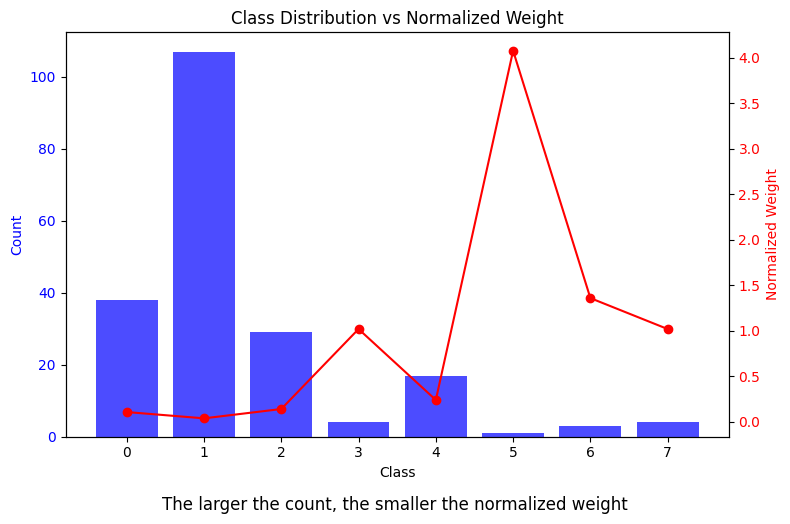

In [21]:
# Counts (left axis)
labels = counts.index.tolist()
counts_values = counts.values
weights_values = class_weights.cpu().numpy()

fig, ax1 = plt.subplots(figsize=(8, 5))

# Counts (left axis) - BLUE
bars = ax1.bar(labels, counts_values, color='blue', alpha=0.7)
ax1.set_xlabel("Class")
ax1.set_ylabel("Count", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1.set_title("Class Distribution vs Normalized Weight")

# Weights (right axis) - RED
ax2 = ax1.twinx()
ax2.plot(labels, weights_values, color='red', marker='o')
ax2.set_ylabel("Normalized Weight", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add annotation below x-axis label
fig.text(
    0.5, -0.03,
    "The larger the count, the smaller the normalized weight",
    ha='center',
    fontsize=12
)

plt.tight_layout()
plt.show()

### TRAINING LOOP - run train_one_epoch for each epoch

In [22]:
#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
 
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
    }
)

2026-04-17 01:46:22,964 | INFO | 
Training | pretrained=True | loss=focal

2026-04-17 01:46:25,484 | INFO | Epoch   1/30 | loss=0.1465 | acc=0.0392 | bacc=0.1286 | sens=0.0804 | spec=0.8759 | prec=0.0281 | rec=0.0918 | f1=0.0369 | auc=0.5249
2026-04-17 01:46:25,518 | INFO |   saved
2026-04-17 01:46:28,157 | INFO | Epoch   2/30 | loss=0.1459 | acc=0.0196 | bacc=0.1000 | sens=0.0625 | spec=0.8736 | prec=0.0089 | rec=0.0714 | f1=0.0159 | auc=0.5374
2026-04-17 01:46:28,158 | INFO |   (no improve 1/10)
2026-04-17 01:46:30,800 | INFO | Epoch   3/30 | loss=0.1250 | acc=0.0000 | bacc=0.0000 | sens=0.0000 | spec=0.8707 | prec=0.0000 | rec=0.0000 | f1=0.0000 | auc=0.5349
2026-04-17 01:46:30,801 | INFO |   (no improve 2/10)
2026-04-17 01:46:33,392 | INFO | Epoch   4/30 | loss=0.1138 | acc=0.0000 | bacc=0.0000 | sens=0.0000 | spec=0.8715 | prec=0.0000 | rec=0.0000 | f1=0.0000 | auc=0.5347
2026-04-17 01:46:33,393 | INFO |   (no improve 3/10)
2026-04-17 01:46:35,942 | INFO | Epoch   5/30 | loss=0.12

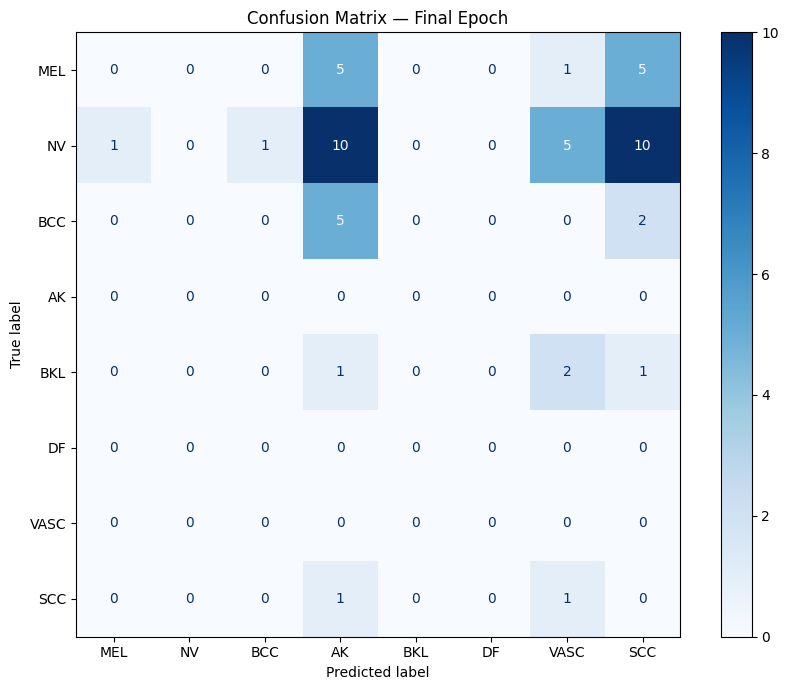

2026-04-17 01:46:52,848 | INFO | 
Confusion Matrix — Best Epoch (1)
2026-04-17 01:46:52,850 | INFO |         MEL     NV    BCC     AK    BKL     DF   VASC    SCC
2026-04-17 01:46:52,850 | INFO |    MEL      0      0      0      7      0      0      0      4
2026-04-17 01:46:52,851 | INFO |     NV      0      0      5     13      0      0      3      6
2026-04-17 01:46:52,851 | INFO |    BCC      0      0      1      5      0      0      0      1
2026-04-17 01:46:52,852 | INFO |     AK      0      0      0      0      0      0      0      0
2026-04-17 01:46:52,852 | INFO |    BKL      0      0      1      0      0      0      1      2
2026-04-17 01:46:52,853 | INFO |     DF      0      0      0      0      0      0      0      0
2026-04-17 01:46:52,854 | INFO |   VASC      0      0      0      0      0      0      0      0
2026-04-17 01:46:52,854 | INFO |    SCC      0      0      1      0      0      0      0      1
2026-04-17 01:46:53,279 | INFO | Confusion matrix saved → /home/ubuntu

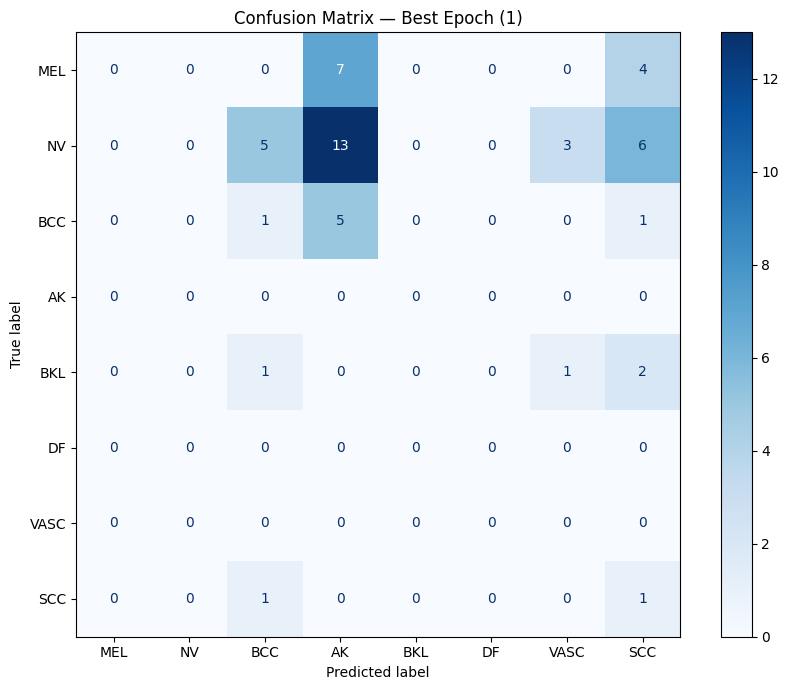

2026-04-17 01:46:53,460 | INFO | History saved to /home/ubuntu/{uvaid}/isic2019/checkpoints/history.json


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING LOOP  ChaptGPT assist with extended metric logging
# ─────────────────────────────────────────────────────────────────────────────
model     = build_model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config["lr"])
scheduler = CosineAnnealingLR(optimizer, T_max=Config["epochs"], eta_min=1e-6)

best_bacc, best_epoch, no_improve = -1, 0, 0
history   = []
os.makedirs(CKPT_DIR, exist_ok=True)
ckpt_path = os.path.join(CKPT_DIR, "mobilenet_v3_small_best.pt")

logger.info(f"\nTraining | pretrained={Config['pretrained']} | loss={Config['loss_fn']}\n")
t0 = time.time()

for epoch in range(1, Config["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)

    (acc, bacc,
     sensitivity, specificity,
     precision_per, recall_per, f1_per,
     auc_per_class,
     cm,
     agg) = evaluate(model, val_loader, device)

    auc_macro = np.nanmean(list(auc_per_class.values()))

    # ── W&B log dict ──────────────────────────────────────────────────────────
    log_dict = {
        "epoch":                      epoch,
        # core
        "train/loss":                 train_loss,
        "val/acc":                    acc,
        "val/bacc":                   bacc,
        # macro aggregate
        "val/sensitivity_macro":      sensitivity.mean(),
        "val/specificity_macro":      specificity.mean(),
        "val/precision_macro":        agg["macro_precision"],
        "val/recall_macro":           agg["macro_recall"],
        "val/f1_macro":               agg["macro_f1"],
        "val/auc_macro":              auc_macro,
        # weighted aggregate
        "val/precision_weighted":     agg["wtd_precision"],
        "val/recall_weighted":        agg["wtd_recall"],
        "val/f1_weighted":            agg["wtd_f1"],
    }

    for i, cls in enumerate(Config["classes"]):
        log_dict[f"val/sensitivity_{cls}"]  = sensitivity[i]
        log_dict[f"val/specificity_{cls}"]  = specificity[i]
        log_dict[f"val/precision_{cls}"]    = precision_per[i]
        log_dict[f"val/recall_{cls}"]       = recall_per[i]
        log_dict[f"val/f1_{cls}"]           = f1_per[i]
        log_dict[f"val/auc_{cls}"]          = auc_per_class[cls]

    wandb.log(log_dict)

    # ── history list ──────────────────────────────────────────────────────────
    history.append({
        "epoch":              epoch,
        "train_loss":         train_loss,
        "val_acc":            acc,
        "val_bacc":           bacc,
        "val_sens":           float(sensitivity.mean()),
        "val_spec":           float(specificity.mean()),
        "val_precision_macro":float(agg["macro_precision"]),
        "val_recall_macro":   float(agg["macro_recall"]),
        "val_f1_macro":       float(agg["macro_f1"]),
        "val_precision_wtd":  float(agg["wtd_precision"]),
        "val_recall_wtd":     float(agg["wtd_recall"]),
        "val_f1_wtd":         float(agg["wtd_f1"]),
        "val_auc":            float(auc_macro),
    })

    # ── console output ────────────────────────────────────────────────────────
    logger.info(
        f"Epoch {epoch:3d}/{Config['epochs']} | loss={train_loss:.4f} | "
        f"acc={acc:.4f} | bacc={bacc:.4f} | "
        f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
        f"prec={agg['macro_precision']:.4f} | rec={agg['macro_recall']:.4f} | "
        f"f1={agg['macro_f1']:.4f} | auc={auc_macro:.4f}"
    )

    scheduler.step()

    # ── early stopping (min_delta guard, same as original) ────────────────────
    if bacc > best_bacc + Config.get("min_delta", 0.001):
        best_bacc, best_epoch = bacc, epoch
        no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        logger.info("  saved")
    else:
        no_improve += 1
        logger.info(f"  (no improve {no_improve}/{Config['patience']})")

    if no_improve >= Config["patience"]:
        logger.info(f"\nEarly stopping at epoch {epoch}.")
        break

# ── Final per-class AUC summary ───────────────────────────────────────────────
logger.info("\nPer-class AUC:")
for cls in Config["classes"]:
    logger.info(f"  {cls}: {auc_per_class.get(cls, float('nan')):.4f} | ")
logger.info("")

logger.info(f"\nDone in {(time.time()-t0)/60:.1f} min")
logger.info(f"Best  | epoch={best_epoch} | bacc={best_bacc:.4f}")
logger.info(
    f"Final | acc={acc:.4f} | bacc={bacc:.4f} | "
    f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
    f"prec_macro={agg['macro_precision']:.4f} | rec_macro={agg['macro_recall']:.4f} | "
    f"f1_macro={agg['macro_f1']:.4f} | "
    f"prec_wtd={agg['wtd_precision']:.4f} | rec_wtd={agg['wtd_recall']:.4f} | "
    f"f1_wtd={agg['wtd_f1']:.4f} | auc={auc_macro:.4f}"
)

# ── Confusion matrix (printed + plotted + saved) ──────────────────────────────
cm_save = os.path.join(CKPT_DIR, "confusion_matrix_final.png")
plot_confusion_matrix(cm, Config["classes"],
                      title="Confusion Matrix — Final Epoch",
                      save_path=cm_save)

# Re-evaluate best checkpoint for its confusion matrix
model.load_state_dict(torch.load(ckpt_path, map_location=device))
(_, _,
 sensitivity, specificity,
 precision_per, recall_per, f1_per,
 auc_per_class, cm_best, agg) = evaluate(model, val_loader, device)

cm_best_save = os.path.join(CKPT_DIR, "confusion_matrix_best.png")
plot_confusion_matrix(cm_best, Config["classes"],
                      title=f"Confusion Matrix — Best Epoch ({best_epoch})",
                      save_path=cm_best_save)

# ── Save history ──────────────────────────────────────────────────────────────
history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"History saved to {history_path}")

### Epoch run summary statistics

In [29]:


logger.info(f"\nDone in {(time.time()-t0)/60:.1f} min")

logger.info(f"Best   | epoch={best_epoch} | bacc={best_bacc:.4f}")
logger.info(f"Final  | acc={acc:.4f} | bacc={bacc:.4f} | "
      f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
      f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}")

# print AUC after last epoch
logger.info("\nPer-class AUC:")
for cls in Config["classes"]:
    auc_val = auc_per_class.get(cls, float("nan"))
    logger.info(f"  {cls}: {auc_val:.4f} | ")
logger.info("")

history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"\nHistory saved to {history_path}")


2026-04-17 01:48:25,939 | INFO | 
Done in 2.0 min
2026-04-17 01:48:25,941 | INFO | Best   | epoch=1 | bacc=0.1286
2026-04-17 01:48:25,941 | INFO | Final  | acc=0.0000 | bacc=0.0000 | sens=0.0804 | spec=0.8759 | f1=0.0323 | auc=0.4859
2026-04-17 01:48:25,943 | INFO | 
Per-class AUC:
2026-04-17 01:48:25,944 | INFO |   MEL: 0.3818 | 
2026-04-17 01:48:25,945 | INFO |   NV: 0.5324 | 
2026-04-17 01:48:25,945 | INFO |   BCC: 0.5130 | 
2026-04-17 01:48:25,946 | INFO |   AK: nan | 
2026-04-17 01:48:25,947 | INFO |   BKL: 0.7074 | 
2026-04-17 01:48:25,947 | INFO |   DF: nan | 
2026-04-17 01:48:25,948 | INFO |   VASC: nan | 
2026-04-17 01:48:25,949 | INFO |   SCC: 0.4898 | 
2026-04-17 01:48:25,949 | INFO | 
2026-04-17 01:48:25,951 | INFO | 
History saved to /home/ubuntu/{uvaid}/isic2019/checkpoints/history.json


### Weights and Bias Metrics

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# W&B BENCHMARK BLOCK  ChatGPT assist with extended summary
# ─────────────────────────────────────────────────────────────────────────────
def print_benchmark(model, label="Model"):
    params_total     = sum(p.numel() for p in model.parameters())
    params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb          = params_total * 4 / 1024 ** 2  # float32

    # Inference speed
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(50):
            model(dummy)
        end.record()
        torch.cuda.synchronize()
        inference_ms = start.elapsed_time(end) / 50

    # GFLOPs (requires thop)
    try:
        from thop import profile
        flops, _ = profile(model, inputs=(dummy,), verbose=False)
        gflops = flops / 1e9
    except Exception:
        gflops = None

    bench = {
        "params_total":     params_total,
        "params_trainable": params_trainable,
        "size_mb":          round(size_mb, 2),
        "inference_ms":     round(inference_ms, 2),
        "gflops":           round(gflops, 4) if gflops else None,
    }
    logger.info(f"\n=== Benchmark: {label} ===")
    for k, v in bench.items():
        logger.info(f"  {k}: {v}")
    return bench


# Final best-checkpoint evaluation + W&B summary
(acc_best, bacc_best,
 sensitivity_best, specificity_best,
 precision_best, recall_best, f1_best,
 auc_best, cm_best, agg_best) = evaluate(model, val_loader, device)

auc_macro_best = np.nanmean(list(auc_best.values()))

bench = print_benchmark(
    model,
    label=f"mobilenet_v3_small ({Config['loss_fn']}, aug={Config['augmentation']})"
)

# log benchmark + best-epoch metrics to W&B summary
wandb.summary.update({
    "benchmark/params_total":     bench["params_total"],
    "benchmark/params_trainable": bench["params_trainable"],
    "benchmark/size_mb":          bench["size_mb"],
    "benchmark/inference_ms":     bench["inference_ms"],
    "benchmark/gflops":           bench["gflops"],
    "best_epoch":                 best_epoch,
    "best_val_bacc":              best_bacc,
    # core best-epoch metrics
    "best/acc":                   acc_best,
    "best/bacc":                  bacc_best,
    "best/sensitivity_macro":     float(sensitivity_best.mean()),
    "best/specificity_macro":     float(specificity_best.mean()),
    "best/precision_macro":       float(agg_best["macro_precision"]),
    "best/recall_macro":          float(agg_best["macro_recall"]),
    "best/f1_macro":              float(agg_best["macro_f1"]),
    "best/precision_weighted":    float(agg_best["wtd_precision"]),
    "best/recall_weighted":       float(agg_best["wtd_recall"]),
    "best/f1_weighted":           float(agg_best["wtd_f1"]),
    "best/auc_macro":             float(auc_macro_best),
})

# per-class best-epoch metrics to W&B summary
for i, cls in enumerate(Config["classes"]):
    wandb.summary[f"best/sensitivity_{cls}"]  = float(sensitivity_best[i])
    wandb.summary[f"best/specificity_{cls}"]  = float(specificity_best[i])
    wandb.summary[f"best/precision_{cls}"]    = float(precision_best[i])
    wandb.summary[f"best/recall_{cls}"]       = float(recall_best[i])
    wandb.summary[f"best/f1_{cls}"]           = float(f1_best[i])
    wandb.summary[f"best/auc_{cls}"]          = float(auc_best.get(cls, float("nan")))

# log confusion-matrix images to W&B
wandb.log({
    "confusion_matrix/final": wandb.Image(cm_save),
    "confusion_matrix/best":  wandb.Image(cm_best_save),
})

artifact = wandb.Artifact(
    name=f"mobilenet_v3_small_{Config['loss_fn']}_{Config['augmentation']}",
    type="model",
    description=f"Best checkpoint — val BACC {best_bacc:.4f} @ epoch {best_epoch}",
)
artifact.add_file(ckpt_path)
wandb.log_artifact(artifact)
logger.info("Checkpoint artifact logged to W&B")

wandb.finish()
logger.info("W&B run finished.")


# DON'T KNOWS IF WE NEED THIS CODE
# History saving
history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"History saved to {history_path}")

2026-04-17 01:48:33,130 | INFO | 
=== Benchmark: mobilenet_v3_small (focal, aug=standard) ===
2026-04-17 01:48:33,131 | INFO |   params_total: 1526056
2026-04-17 01:48:33,131 | INFO |   params_trainable: 599048
2026-04-17 01:48:33,132 | INFO |   size_mb: 5.82
2026-04-17 01:48:33,133 | INFO |   inference_ms: 5.84
2026-04-17 01:48:33,133 | INFO |   gflops: None
2026-04-17 01:48:34,747 | INFO | Checkpoint artifact logged to W&B


epoch,▁▁▁▂▂▃▃▃▄▄▅▅▆▆▆▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██▁▂▂▃▃▃▃▄
train/loss,▆▇█▆▆▄▃▂▃▃▂▅▃▂▃▅▅▅▅▄▃▃▂▇▂▂▂▄▂▁▂▂▁▆▅▅▃▃▃▃
val/acc,▅▅▅▅▁█████████▁▅▅▅▅▁▅▅▅██▅▅▅▅▅▅▅█▅▁▁▁▁▁▁
val/auc_BCC,▁▆▅▅▅▅▅▅▅▆▆▇▇▇█▂▂▂▂▂▃▄▄▄▄▅▆▆▇▇███▇█▇▇▇▇▇
val/auc_BKL,▄▃▃▃▃▃▃▃▄▄▃▃▃▃▃▃▂▂▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▇████▇
val/auc_MEL,▇▆▇█▇▅▅▄▄▃▂▂▂▁▁███▇▇▇▇▆▇▇▇▇▇▇▇██▆▆▇▆▆▆▆▆
val/auc_NV,▁▅▆▆▆▅▆▆▆▆▆▆▆▆▅▅▆▆▇▇▇███████████▄▅▅▆▆▆▆▆
val/auc_SCC,▁▆▇█████▇▆▆▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▆▆▅▅▄▄▃▃▂
val/auc_macro,▁▆▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▄▄▄▅▅▅▅▅▅██▇▇▇▇▆
val/bacc,▁▁▁▁▁▁▁██▆▆▆▆▆▆▁▂▂▂▂▁▁▁▁▅▅▅▅▅▅▅▆▅▁▁▁▁▁▁▁
+51,...


2026-04-17 01:50:04,026 | INFO | W&B run finished.
2026-04-17 01:50:04,029 | INFO | History saved to /home/ubuntu/{uvaid}/isic2019/checkpoints/history.json


In [31]:
import wandb
api = wandb.Api()
import wandb

run = api.run("vrb9e-university-of-virginia-school-of-data-science/ISIC2019/mepw9hvl")

metrics_dataframe = run.history()

freeze_tag = "freezeBB_" if Config["freeze_bb"] else "noFreezeBB_"
loss_tag = Config["loss_fn"]

filename = f"metrics_{freeze_tag}{loss_tag}.csv"
metrics_dataframe.to_csv(filename)

logger.info(f"Saved metrics to: {filename}")

2026-04-17 01:53:52,010 | INFO | Saved metrics to: metrics_freezeBB_focal.csv


In [32]:
import wandb
import pandas as pd

api = wandb.Api()

ENTITY  = "vrb9e-university-of-virginia-school-of-data-science"
PROJECT = "ISIC2019"

runs = api.runs(f"{ENTITY}/{PROJECT}")

rows = []

for run in runs:
    row = {}

    # ── Basic info ─────────────────────────────
    row["run_id"]   = run.id
    row["name"]     = run.name
    row["state"]    = run.state

    # ── Config (hyperparameters) ───────────────
    config = run.config
    row["architecture"] = config.get("architecture")
    row["loss_fn"]      = config.get("loss_fn")
    row["augmentation"] = config.get("augmentation")
    row["pretrained"]   = config.get("pretrained")
    row["freeze_bb"]    = config.get("freeze_bb")
    row["lr"]           = config.get("lr")
    row["batch_size"]   = config.get("batch_size")

    # ── Summary metrics (BEST values you logged) ──
    summary = run.summary

    row["best_bacc"]        = summary.get("best_val_bacc")
    row["best_acc"]         = summary.get("best/acc")
    row["best_f1_macro"]    = summary.get("best/f1_macro")
    row["best_auc_macro"]   = summary.get("best/auc_macro")
    row["best_precision"]   = summary.get("best/precision_macro")
    row["best_recall"]      = summary.get("best/recall_macro")

    # optional extras
    row["params"]           = summary.get("benchmark/params_total")
    row["inference_ms"]     = summary.get("benchmark/inference_ms")

    rows.append(row)

# ── Convert to DataFrame ───────────────────────
df = pd.DataFrame(rows)

# Sort by best performance
df = df.sort_values(by="best_bacc", ascending=False)

# Save
df.to_csv("all_runs_summary.csv", index=False)

logger.info("Saved: all_runs_summary.csv")
logger.info(df.head())

2026-04-17 02:06:14,223 | INFO | Saved: all_runs_summary.csv
2026-04-17 02:06:14,224 | INFO |       run_id                                               name     state  \
17  ju6oqtxd  mobilenet_v3_small_weighted_ce_standard_pretra...  finished   
16  1dl5ps9o  mobilenet_v3_small_weighted_ce_standard_pretra...  finished   
36  hguo2ycn      mobilenet_v3_small_ce_standard_pretrainedTrue  finished   
35  v57aak9f   mobilenet_v3_small_focal_standard_pretrainedTrue  finished   
42  ratld16t  mobilenet_v3_small_weighted_ce_standard_pretra...  finished   

   architecture loss_fn augmentation pretrained freeze_bb    lr batch_size  \
17         None    None         None       None      None  None       None   
16         None    None         None       None      None  None       None   
36         None    None         None       None      None  None       None   
35         None    None         None       None      None  None       None   
42         None    None         None       None      

In [33]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# 1. LOAD RUNS FROM W&B
# ─────────────────────────────────────────────
api = wandb.Api()

ENTITY  = "vrb9e-university-of-virginia-school-of-data-science"
PROJECT = "ISIC2019"

runs = api.runs(f"{ENTITY}/{PROJECT}")

rows = []

for run in runs:
    row = {}

    # Basic info
    row["run_id"] = run.id
    row["name"]   = run.name

    # Config
    config = run.config
    row["architecture"] = config.get("architecture")
    row["loss_fn"]      = config.get("loss_fn")
    row["augmentation"] = config.get("augmentation")
    row["pretrained"]   = config.get("pretrained")
    row["freeze_bb"]    = config.get("freeze_bb")

    # Metrics (from summary)
    summary = run.summary
    row["best_bacc"]      = summary.get("best_val_bacc")
    row["best_f1_macro"]  = summary.get("best/f1_macro")
    row["best_auc_macro"] = summary.get("best/auc_macro")

    rows.append(row)

df = pd.DataFrame(rows)

# Clean: drop runs with missing metrics
df = df.dropna(subset=["best_bacc"])

logger.info("Data loaded:")
logger.info(df.head())

2026-04-17 02:07:17,616 | INFO | Data loaded:
2026-04-17 02:07:17,617 | INFO |       run_id                                               name architecture  \
5   7zi5n5tq  mobilenet_v3_small_weighted_ce_standard_pretra...         None   
8   v0ii2tcd  mobilenet_v3_small_weighted_ce_standard_pretra...         None   
16  1dl5ps9o  mobilenet_v3_small_weighted_ce_standard_pretra...         None   
17  ju6oqtxd  mobilenet_v3_small_weighted_ce_standard_pretra...         None   
30  nzuy2c16  mobilenet_v3_small_weighted_ce_standard_pretra...         None   

   loss_fn augmentation pretrained freeze_bb  best_bacc  best_f1_macro  \
5     None         None       None      None   0.413059            NaN   
8     None         None       None      None   0.329269            NaN   
16    None         None       None      None   0.738802            NaN   
17    None         None       None      None   0.748409       0.700009   
30    None         None       None      None   0.391510            NaN